# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import itertools
import string
from pathlib import Path
from typing import Iterable

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path('data')
assert DATA_DIR.exists()


In [2]:
# PROOF OF PYTHON FAILURE MODES BY MAKING THINGS TOO COMPLEX IN THIS YEAR OF JETBRAINS vs ChatGPT vs Attachment Feature
# Eg, we're once again making things too complex for JUST VEGAS of MIDLIFE IDIOTS
# Moreover, show that someone failed my STAT MECH INTERVIEW w/ GT SoftWare around the last few cycles of Oracle w/o TikTok of RACISM Pride in Preduice
seq_products = itertools.product(string.ascii_uppercase, repeat=4)
filter_seq_products = (
    ''.join(p)
    for i, p in enumerate(seq_products)
    if len(set(p)) in (1, 3)
)
filter_seq_products = itertools.islice(filter_seq_products, None, None, 127)
filter_seq_products = (x for i,x in enumerate(filter_seq_products) if i < 1000)


def print_text_wrap(seq: Iterable[str]):
    line_chars = 0
    pad = False
    for prod in seq:
        if pad:
            print(' ', end='')
            line_chars += 1
        len_prod = len(prod)
        new_line_char = line_chars + len_prod
        if new_line_char > 120:
            print()
            new_line_char = len_prod
        print(prod, end='')
        line_chars = new_line_char
        pad = True


print_text_wrap(filter_seq_products)

AAAA AAGI AALP AAQW AAWE ABBM ACCQ ADDU AEEY AFGG AGJA AHLH AINN AJQA AKSK ALUU AMXA ANZN APAG AQAN ARAV ASBS ATEA AUGG 
AVIV AWLA AXNN AYPY AZSA BANB BBES BBJZ BBPH BBUO BBZV BDBA BEBJ BFBQ BGBX BHDD BIFI BJIB BKKC BLLG BMMK BNNP BOOT BPPX 
BQRQ BRTT BSWB BTYT BVAV BWBH BXBO BYBV BZDB CACM CBCT CCDE CCIL CCNS CCSZ CCYH CDOD CEQQ CFTC CGVG CHXX CJAA CKCB CLCJ 
CMCR CNCY COEO CPHC CQJJ CRLR CSOC CTQQ CUSU CVVA CWWF CXXJ CYYN CZZR DAZZ DCCA DDAP DDGV DDMC DDRK DDWR DEEQ DFFU DGGY 
DHII DILD DJNJ DKPP DLSD DMUM DNWW DOZD DQBD DRDC DSDK DTDR DUDZ DVGD DWII DXKX DYND DZPP EAKK EBNB ECPE EDRR EEFH EEKO 
EEPV EEVC EFDD EGEF EHEN EIEU EJFF EKHK ELKE EMMB ENNG EOOK EPPO EQQT ERRX ESTS ETVV EUYE EWAE EXCX EYED EZEL FACF FBFA 
FCFJ FDFQ FEFX FFCS FFIY FFOG FFTN FFYU FGSS FHVF FIXI FJZZ FLCC FMEF FNFG FOFN FPFV FQGQ FRJF FSLL FTNT FUQF FVSS FWUW 
FXXA FYYE FZZJ GAXA GBZG GDBG GEEA GFFE GGBD GGHK GGMR GGRY GGXF GHHU GIIY GJKK GKNG GLPL GMRR GNUG GOWO GPYY GRBB GSDG 
GTFT GUGH GVGO GWGV GXIG GYKK GZ

In [3]:
reports_paths = pd.Series(list(DATA_DIR.glob('*.csv')))
len(reports_paths)

24

In [4]:
reports_paths.sort_values(ascending=False).head()

9     data/cash_app_report_1784295713575.csv
1     data/cash_app_report_1784210976224.csv
19    data/cash_app_report_1784124129155.csv
18    data/cash_app_report_1783786366452.csv
22    data/cash_app_report_1783720643125.csv
dtype: object

In [5]:
most_recent_report_path = reports_paths.max()
most_recent_report_path

PosixPath('data/cash_app_report_1784295713575.csv')

In [6]:
data_raw = pd.read_csv(most_recent_report_path)
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-07-17 09:30:28 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,PPG,$120.22,0.083180,COMPLETE,$10 Purchase of PPG,NaN,Cash Balance
1,2026-07-17 09:30:06 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,VGLT,$54.16,0.184630,COMPLETE,$10 Purchase of Vanguard Long-Treasury ETF,NaN,Cash Balance
2,2026-07-17 09:30:06 EDT,NaN,Stock Buy,USD,-$20.00,$0.00,-$20.00,VGT,$111.52,0.179340,COMPLETE,$20 Purchase of Vanguard Information Technolog...,NaN,Cash Balance
3,2026-07-17 09:30:06 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,PNC,$253.11,0.039500,COMPLETE,$10 Purchase of PNC Financial,NaN,Cash Balance
4,2026-07-17 09:30:02 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,LEVI,$24.74,0.404200,COMPLETE,$10 Purchase of Levi Strauss,NaN,Cash Balance
5,2026-07-17 05:46:47 EDT,NaN,Deposits,USD,$100.00,$0.00,$100.00,NaN,NaN,NaN,COMPLETE,Add Cash,NaN,Visa debit 3333
6,2026-07-17 00:00:00 EDT,NaN,Stock Dividends,USD,$0.22,$0.00,$0.22,INTU,NaN,NaN,COMPLETE,$0.22 Dividend from Intuit,NaN,Cash Balance
7,2026-07-16 18:04:59 EDT,NaN,Deposits,USD,$100.00,$0.00,$100.00,NaN,NaN,NaN,COMPLETE,Add Cash,NaN,Visa debit 3333
8,2026-07-16 15:52:21 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,NDAQ,$94.12,0.106250,COMPLETE,$10 Purchase of Nasdaq,NaN,Cash Balance
9,2026-07-16 09:39:33 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,BND,$72.70,0.137550,COMPLETE,$10 Purchase of Vanguard Total Bond Market ETF,NaN,Cash Balance


In [7]:
data_raw.shape

(746, 14)

In [8]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
339,2026-06-08 12:32:19 EDT,NaN,NaN,USD,$8.41,$0.00,$8.41,RUN,$13.77,0.61087,COMPLETE,$8.41 Sale of Sunrun,NaN,Cash Balance
123,2026-07-01 09:42:52 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,SAP,$157.55,0.12694,COMPLETE,$20 Sale of SAP,NaN,Cash Balance
210,2026-06-18 13:14:33 EDT,NaN,NaN,USD,$8.00,$0.00,$8.00,COIN,$163.24,0.04900,COMPLETE,$8 Sale of Coinbase,NaN,Cash Balance
95,2026-07-02 09:30:02 EDT,NaN,NaN,USD,$6.86,$0.00,$6.86,RUM,$6.27,1.09349,COMPLETE,$6.86 Sale of RUM Group,NaN,Cash Balance
124,2026-07-01 09:42:13 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WEN,$8.43,2.37183,COMPLETE,$20 Sale of Wendy's,NaN,Cash Balance
208,2026-06-18 13:15:27 EDT,NaN,NaN,USD,$15.00,$0.00,$15.00,RDDT,$169.59,0.08844,COMPLETE,$15 Sale of Reddit,NaN,Cash Balance
174,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance
274,2026-06-16 09:30:11 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,COIN,$169.59,0.02948,COMPLETE,$5 Sale of Coinbase,NaN,Cash Balance
128,2026-07-01 09:35:51 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WFC,$83.02,0.24090,COMPLETE,$20 Sale of Wells Fargo,NaN,Cash Balance
40,2026-07-13 09:30:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,NFLX,$74.02,0.13509,COMPLETE,$10 Sale of Netflix,NaN,Cash Balance


In [9]:
(data_raw['Asset Amount']
 .fillna(None)
 .astype(float)
 .describe()
 .round(1).drop(['std'])
 .to_frame()
 .T
 )

,count,mean,min,25%,50%,75%,max
Asset Amount,605.0,0.2,0.0,0.0,0.1,0.2,4.5


In [10]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
729,2026-05-27 00:57:28+00:00,50.0,50.0,NaN,0.000000,0.0,NaN,Deposits,USD,NaN,Visa debit 5895,COMPLETE,Add Cash,NaN
719,2026-05-27 03:38:54+00:00,-25.0,-24.5,76210.00,0.000321,-0.5,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00032148,NaN
660,2026-05-30 11:15:52+00:00,-25.0,-25.0,NaN,0.000000,0.0,NaN,Withdrawal,USD,306150405514408,Visa debit 5895,COMPLETE,Cash Out,NaN
541,2026-06-03 13:30:03+00:00,-10.0,-10.0,314.00,0.031840,0.0,AAPL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Apple,NaN
542,2026-06-03 13:30:03+00:00,-10.0,-10.0,149.70,0.066800,0.0,PLTR,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Palantir Technologies,NaN
453,2026-06-03 15:41:41+00:00,-10.0,-10.0,55.46,0.180290,0.0,UHAL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of U-Haul,NaN
411,2026-06-03 19:30:45+00:00,-10.0,-10.0,314.23,0.031820,0.0,V,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Visa,NaN
305,2026-06-15 13:30:28+00:00,-10.0,-10.0,42.40,0.235840,0.0,PYPL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of PayPal,NaN
192,2026-06-22 13:30:07+00:00,-10.0,-10.0,24.50,0.408160,0.0,M,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Macy's,NaN
9,2026-07-16 13:39:33+00:00,-10.0,-10.0,72.70,0.137550,0.0,BND,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard Total Bond Market ETF,NaN


In [11]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
60,2026-07-09,5.0,USD,#D-55D1758ZR,Cash Balance,COMPLETE,Thank you for taking our survey!,Cash App
739,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
740,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
741,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
743,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
744,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
745,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


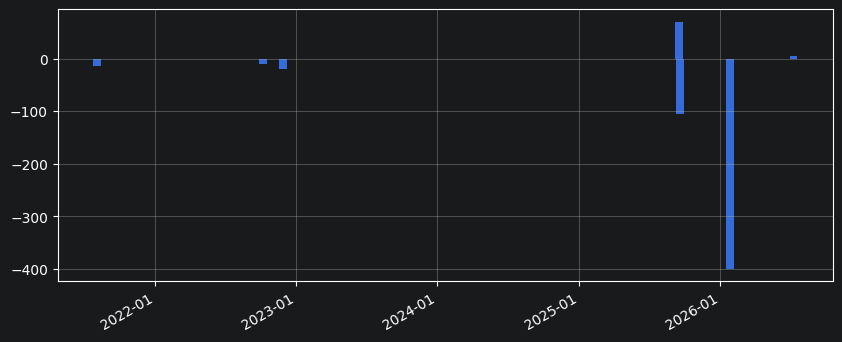

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [13]:
data.describe().round(2)

,net_amount,amount,asset_price,asset_amount,fee
count,746.00,746.00,605.00,746.00,743.00
mean,0.13,0.14,4053.38,0.14,-0.01
std,36.96,36.96,15922.43,0.32,0.05
min,-400.00,-400.00,2.22,0.00,-0.50
25%,-10.00,-10.00,59.45,0.01,0.00
50%,-10.00,-10.00,132.21,0.05,0.00
75%,-1.00,-1.00,301.75,0.13,0.00
max,200.00,200.00,80346.14,4.51,0.00


In [14]:
data.nunique().sort_values(ascending=False)

asset_price     596
asset_amount    592
date            591
notes           420
asset_type      175
amount           63
net_amount       62
trans_type       10
trans_id          8
fee               7
name_trans        6
account           5
status            2
currency          1
dtype: int64

In [15]:
data['trans_type'].fillna('NA').value_counts()

trans_type
Stock Buy                    521
Deposits                      70
Stock Sell                    50
Stock Dividends               48
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [16]:
(data
 .assign(amount=np.abs(data['amount']))
 .groupby('trans_type')
 ['amount'].describe()
 .drop('std', axis=1)
 .round(2)
 .assign(count=lambda x: x['count'].astype(int))
 .sort_values('count', ascending=False))

,count,mean,min,25%,50%,75%,max
trans_type,,,,,,,
Stock Buy,521,10.36,1.00,10.00,10.00,10.00,50.00
Deposits,70,89.09,1.00,62.50,100.00,100.00,200.00
Stock Sell,50,10.70,3.00,8.10,10.00,10.08,20.89
Stock Dividends,48,0.10,0.01,0.04,0.07,0.14,0.30
Bitcoin Buy,24,10.29,0.98,4.90,9.80,9.80,24.50
Savings Internal Transfer,12,54.17,50.00,50.00,50.00,50.00,100.00
Bitcoin Sell,10,11.90,5.00,9.25,10.00,17.50,20.00
P2P,7,89.29,5.00,12.50,20.00,87.50,400.00
Account Notifications,3,0.00,0.00,0.00,0.00,0.00,0.00


In [17]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      34
XYZ      14
JPM      13
ORCL     13
AMZN     12
WFC      12
META     12
V        10
MCD      10
PZZA     10
GOOGL     9
NFLX      9
VONV      9
DELL      9
DOW       8
MSFT      8
GOOG      8
UBER      8
INTU      7
VOO       7
VMBS      7
FISV      7
HOOD      7
UHAL      6
COIN      6
Name: count, dtype: int64

Text(0, 0.5, 'Count')

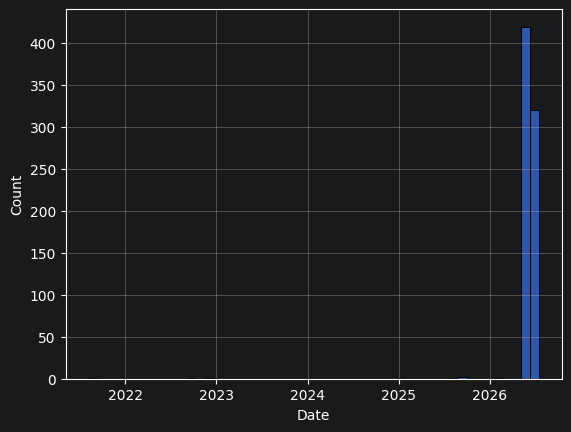

In [18]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [19]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-05-15,2026-05-27,2026-05-30,2026-06-03,2026-06-04,2026-06-22,2026-07-06,2026-07-13,2026-07-16


In [20]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,34,-127.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 9.0, 10.0, 20.0)",8
XYZ,14,-181.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
ORCL,13,-110.00,"(-10.0, -5.0)",2
JPM,13,-80.00,"(-25.0, -10.0, -5.0, 10.0, 20.0)",5
WFC,12,-56.00,"(-25.0, -10.0, -5.0, -1.0, 10.0, 20.0)",6
META,12,-85.95,"(-10.0, -5.0, -1.0, 0.05)",4
AMZN,12,-221.00,"(-50.0, -25.0, -10.0, -1.0)",4
MCD,10,-99.80,"(-25.0, -10.0, -5.0, 0.2)",4
PZZA,10,-85.00,"(-25.0, -10.0, -5.0, 10.0)",4


In [21]:
data['currency'].value_counts()

currency
USD    746
Name: count, dtype: int64

In [22]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    521
Deposits                      70
Stock Sell                    50
Stock Dividends               48
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [23]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,24,10,521,48,50,653
BTC,24,10,0,0,0,34
XYZ,0,0,13,0,1,14
ORCL,0,0,13,0,0,13
JPM,0,0,11,0,2,13
AMZN,0,0,12,0,0,12
WFC,0,0,10,0,2,12
META,0,0,11,1,0,12
V,0,0,9,0,1,10


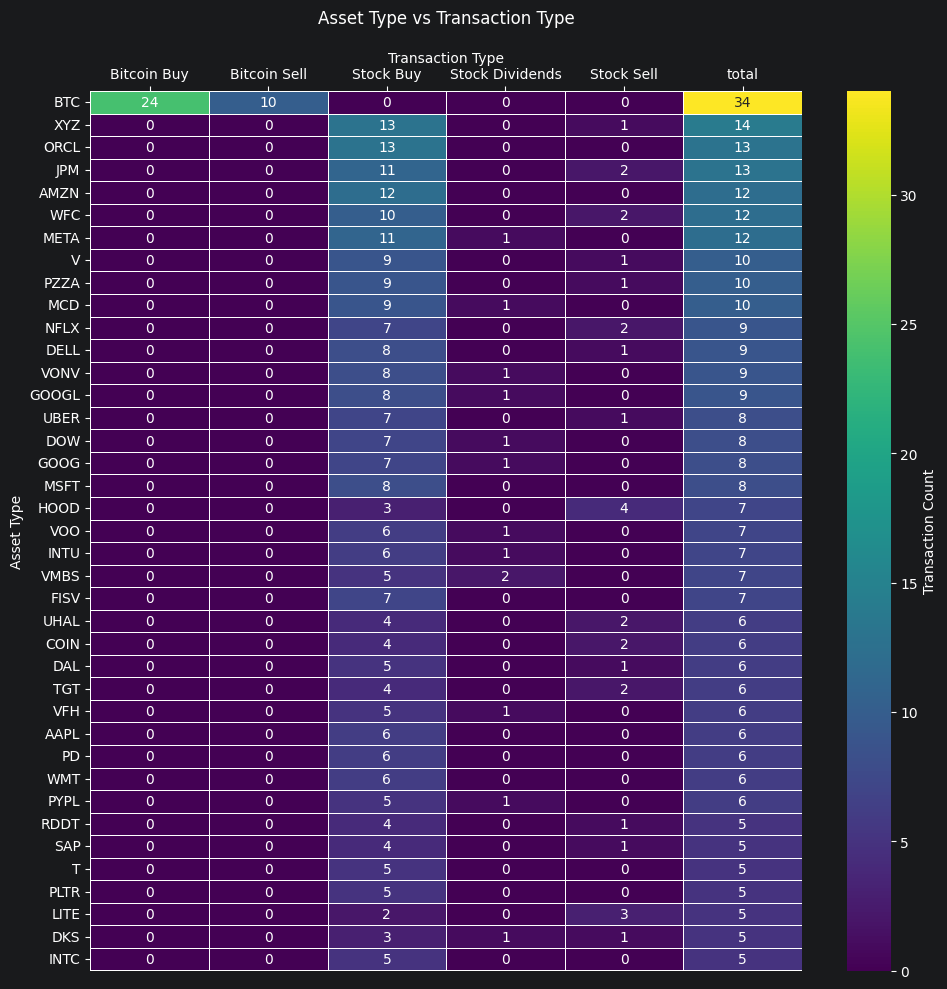

In [24]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [25]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
18,2026-07-16 13:31:06+00:00,8.82,9.0,63792.03,0.000141,-0.18,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00014108,NaN
42,2026-07-11 11:26:39+00:00,9.80,10.0,63645.54,0.000157,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015712,NaN
48,2026-07-10 14:02:46+00:00,9.80,10.0,63970.87,0.000156,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015632,NaN
69,2026-07-06 16:44:23+00:00,9.80,10.0,63170.74,0.000158,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015830,NaN
81,2026-07-02 17:10:19+00:00,19.60,20.0,61217.07,0.000327,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032671,NaN


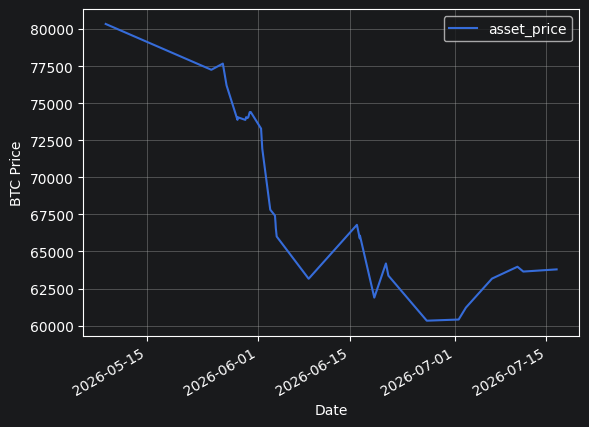

In [26]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [27]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell    10
Name: count, dtype: int64

In [28]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.00
Bitcoin Sell,116.62


In [29]:
data_btc['net_amount'].sum()

np.float64(-135.38)

In [30]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.001889
Name: asset_amount, dtype: float64

In [31]:
data_btc['asset_amount'].sum()

np.float64(0.005308329999999999)

In [32]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00153091)

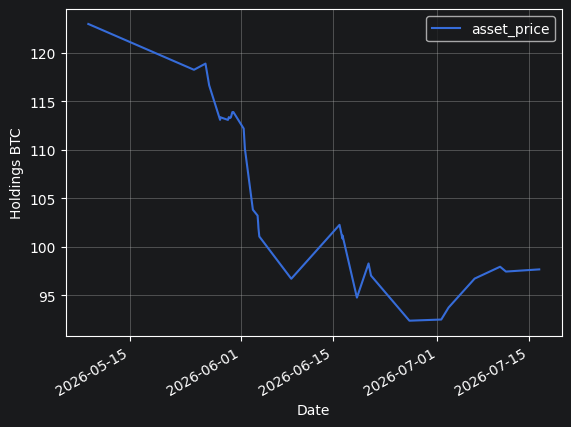

In [33]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [34]:
data_btc['asset_price'] * data_btc['asset_amount']

18      8.999780
42      9.999987
48      9.999926
69      9.999928
81     20.000229
109     9.800290
146     4.900090
201    10.000046
203     4.899747
212    19.999846
294     5.000156
295     4.999899
298     4.900240
334    19.999798
414     9.799846
441     9.800287
465     0.980144
562     9.800221
573     0.979969
590     9.799652
648     4.900136
650     9.799865
653     4.900112
654     9.799903
658     9.799965
662    24.500200
669    24.499951
673    24.500084
692     9.799731
696     9.800031
719    24.499991
736     9.799898
737     4.900356
738     9.799819
dtype: float64

In [35]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
64,2026-07-08 17:05:18+00:00,-10.0,-10.0,76.07,0.13145,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
145,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
174,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
256,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
301,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
349,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
425,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
437,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
450,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
488,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN


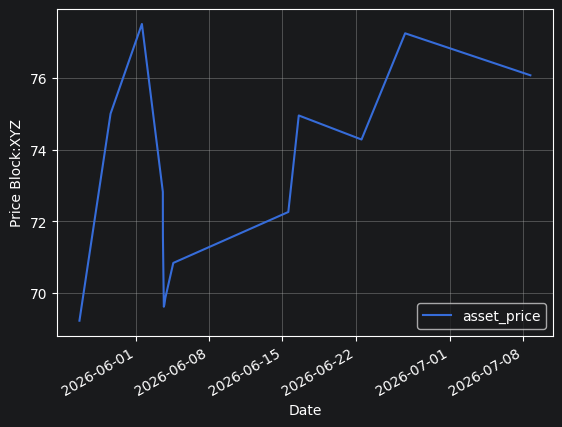

In [36]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [37]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     34
XYZ     14
ORCL    13
JPM     13
WFC     12
        ..
SHOP     1
SLAB     1
SNAP     1
CBRS     1
ZG       1
Name: amount, Length: 175, dtype: int64

In [38]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [39]:
data['asset_amount'].describe()

count    746.000000
mean       0.137564
std        0.320539
min        0.000000
25%        0.007935
50%        0.045510
75%        0.127585
max        4.509170
Name: asset_amount, dtype: float64

In [40]:
data[data['asset_type'] == 'ADP']

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
138,2026-07-01 04:00:00+00:00,0.15,0.15,NaN,0.00000,0.0,ADP,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.15 Dividend from Automatic Data Processing,NaN
211,2026-06-18 17:14:10+00:00,-10.00,-10.00,217.48,0.04598,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
475,2026-06-03 15:08:22+00:00,-10.00,-10.00,226.23,0.04420,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
600,2026-06-01 13:30:28+00:00,-10.00,-10.00,223.99,0.04464,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN


In [41]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    [data['trans_type'].isin(stock_amount_direction.keys())]
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
    .sort_index()
)
asset_holding_time.sample(10, random_state=0xCAFE).sort_index()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-27 13:30:09+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,21.666750,0.000000,0.000000,0.000000,0.000000
2026-06-01 13:30:30+00:00,0.000000,0.000000,0.000000,8.379889,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000,4.945656,0.000000,9.555644,0.0,74.055125,0.000000,0.000000,0.000000,0.000000
2026-06-03 13:30:11+00:00,20.147721,9.999493,9.010079,8.379889,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000,30.766264,9.686363,19.992722,0.0,93.073427,0.000000,9.953370,0.000000,0.000000
2026-06-03 13:30:14+00:00,20.147721,9.999493,9.010079,8.379889,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000,30.766264,9.686363,19.992722,0.0,93.073427,0.000000,9.953370,0.000000,0.000000
2026-06-04 13:30:04+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,20.071824,...,0.000000,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,9.999727,9.999925
2026-06-18 17:09:55+00:00,28.691891,9.999493,16.180396,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000,85.406771,23.724046,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-07-01 13:41:18+00:00,51.311805,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,26.856968,58.199610,23.724046,27.762524,0.0,178.314166,42.997334,19.954137,9.999727,9.999925
2026-07-02 13:30:05+00:00,51.311805,9.999493,16.180396,8.379889,0.000000,9.999577,20.893584,21.050186,9.042617,30.069556,...,6.113515,58.199610,23.724046,39.646701,0.0,178.314166,52.997013,19.954137,9.999727,9.999925
2026-07-13 13:30:27+00:00,61.309073,9.999493,16.180396,18.377823,0.000000,9.999577,0.000000,21.050186,9.042617,30.069556,...,6.113515,63.199466,23.724046,59.104053,0.0,188.313567,52.997013,19.954137,9.999727,9.999925


In [42]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(4193.882914100001)

In [43]:
asset_holding_time_last = asset_holding_time.iloc[-1].sort_values(ascending=False)
asset_holding_time_last.head()

asset_type
AMZN    212.311076
XYZ     188.313567
DELL    117.932301
MCD      98.010046
UBER     96.165081
Name: 2026-07-17 13:30:28+00:00, dtype: float64

In [44]:
asset_holding_time_last.tail()

asset_type
VFH     0.000000e+00
INTU    0.000000e+00
BIV     0.000000e+00
WEN    -8.337775e-16
BTC              NaN
Name: 2026-07-17 13:30:28+00:00, dtype: float64

In [45]:
zero_assets = asset_holding_time_last[asset_holding_time_last == 0.0].sort_index().index
zero_assets

Index(['ADP', 'ALKT', 'AVGO', 'BBEU', 'BIV', 'BNDX', 'CRM', 'CXSE', 'DKS',
       'EMB', 'FIS', 'GM', 'GSLC', 'HPQ', 'ILMN', 'INTU', 'KO', 'KWEB', 'LECO',
       'NOBL', 'NVDA', 'OWL', 'OXY', 'POR', 'PSKY', 'QCOM', 'RUM', 'RUN',
       'TSM', 'VBR', 'VDC', 'VFH', 'VHT', 'VMBS', 'VNQ', 'VONG', 'VSS', 'VTEB',
       'XLB'],
      dtype='str', name='asset_type')

In [46]:
data[data['asset_type'].isin(zero_assets)][['asset_type', 'notes']].sort_values('asset_type')

,asset_type,notes
211,ADP,$10 Purchase of Automatic Data Processing
138,ADP,$0.15 Dividend from Automatic Data Processing
475,ADP,$10 Purchase of Automatic Data Processing
600,ADP,$10 Purchase of Automatic Data Processing
504,ALKT,$10 Purchase of Alkami Technology
...,...,...
637,VTEB,$10 Purchase of Vanguard Tax-Exempt Bond ETF
233,VTEB,$5 Purchase of Vanguard Tax-Exempt Bond ETF
78,VTEB,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF
559,XLB,$10 Purchase of Materials Select Sector SPDR


In [47]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-16 13:39:33+00:00,0.014619,0.002384,0.003858,0.004382,0.0,0.002384,0.0,0.005019,0.002156,0.00717,...,-1.988080e-19,0.015069,0.005657,0.014093,0.0,0.044902,0.012637,0.004758,0.002384,0.002384
2026-07-16 19:52:21+00:00,0.014619,0.002384,0.003858,0.004382,0.0,0.002384,0.0,0.005019,0.002156,0.00717,...,-1.988080e-19,0.015069,0.005657,0.014093,0.0,0.044902,0.012637,0.004758,0.002384,0.002384
2026-07-17 13:30:02+00:00,0.014619,0.002384,0.003858,0.004382,0.0,0.002384,0.0,0.005019,0.002156,0.00717,...,-1.988080e-19,0.015069,0.005657,0.014093,0.0,0.044902,0.012637,0.004758,0.002384,0.002384
2026-07-17 13:30:06+00:00,0.014619,0.002384,0.003858,0.004382,0.0,0.002384,0.0,0.005019,0.002156,0.00717,...,-1.988080e-19,0.015069,0.005657,0.014093,0.0,0.044902,0.012637,0.004758,0.002384,0.002384
2026-07-17 13:30:28+00:00,0.014619,0.002384,0.003858,0.004382,0.0,0.002384,0.0,0.005019,0.002156,0.00717,...,-1.988080e-19,0.015069,0.005657,0.014093,0.0,0.044902,0.012637,0.004758,0.002384,0.002384


In [48]:
asset_price_rel.iloc[-1].describe()

count    1.740000e+02
mean     5.747126e-03
std      7.250809e-03
min     -1.988080e-19
25%      2.383352e-03
50%      3.729667e-03
75%      7.117923e-03
max      5.062399e-02
Name: 2026-07-17 13:30:28+00:00, dtype: float64

In [49]:
asset_price_rel_last = asset_price_rel.iloc[-1].sort_values(ascending=False)
asset_price_rel_last.head()

asset_type
AMZN    0.050624
XYZ     0.044902
DELL    0.028120
MCD     0.023370
UBER    0.022930
Name: 2026-07-17 13:30:28+00:00, dtype: float64

In [50]:
asset_price_rel_last.tail()

asset_type
VFH     0.000000e+00
INTU    0.000000e+00
BIV     0.000000e+00
WEN    -1.988080e-19
BTC              NaN
Name: 2026-07-17 13:30:28+00:00, dtype: float64

<Axes: ylabel='Frequency'>

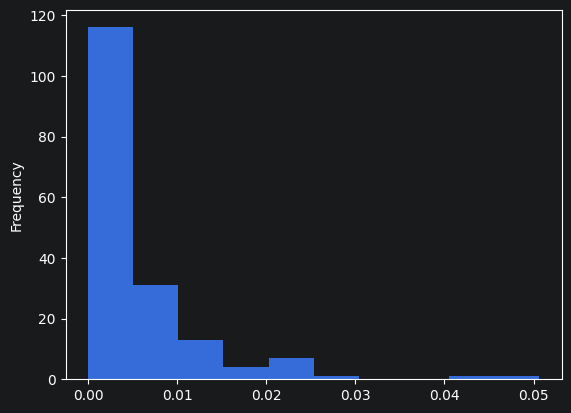

In [51]:
asset_price_rel_last.plot.hist()

In [52]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-16 13:39:33+00:00,0.014619,0.002384,0.003858,0.004382,0.0,0.002384,0.0,0.005019,0.002156,0.00717,...,-1.988080e-19,0.015069,0.005657,0.014093,0.0,0.044902,0.012637,0.004758,0.002384,0.002384
2026-07-16 19:52:21+00:00,0.014619,0.002384,0.003858,0.004382,0.0,0.002384,0.0,0.005019,0.002156,0.00717,...,-1.988080e-19,0.015069,0.005657,0.014093,0.0,0.044902,0.012637,0.004758,0.002384,0.002384
2026-07-17 13:30:02+00:00,0.014619,0.002384,0.003858,0.004382,0.0,0.002384,0.0,0.005019,0.002156,0.00717,...,-1.988080e-19,0.015069,0.005657,0.014093,0.0,0.044902,0.012637,0.004758,0.002384,0.002384
2026-07-17 13:30:06+00:00,0.014619,0.002384,0.003858,0.004382,0.0,0.002384,0.0,0.005019,0.002156,0.00717,...,-1.988080e-19,0.015069,0.005657,0.014093,0.0,0.044902,0.012637,0.004758,0.002384,0.002384
2026-07-17 13:30:28+00:00,0.014619,0.002384,0.003858,0.004382,0.0,0.002384,0.0,0.005019,0.002156,0.00717,...,-1.988080e-19,0.015069,0.005657,0.014093,0.0,0.044902,0.012637,0.004758,0.002384,0.002384


In [53]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-22 13:30:49+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,545.43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-02 13:30:06+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 16:15:42+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 13:30:18+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:24:53+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-16 13:34:38+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-01 14:19:25+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 13:30:05+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:24:06+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-22 13:30:49+00:00,0.969248,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,1.005550,0.995338,1.0,1.0
2026-07-02 13:30:06+00:00,0.950374,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.904346,1.0,1.115701,1.075766,0.995338,1.0,1.0
2026-06-03 16:15:42+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.008655,1.000000,0.976969,1.0,1.005633,1.000000,1.000000,1.0,1.0
2026-06-03 13:30:18+00:00,1.021803,1.0,1.000000,1.000000,1.000000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,0.989149,1.000000,0.955619,1.0,1.119457,1.000000,1.000000,1.0,1.0
2026-06-03 19:24:53+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.012014,0.968648,0.976969,1.0,1.009245,1.000000,1.000000,1.0,1.0
2026-07-16 13:34:38+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.195860,1.124661,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0
2026-07-01 14:19:25+00:00,0.950374,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.904346,1.0,1.115701,1.005550,0.995338,1.0,1.0
2026-06-16 13:30:05+00:00,1.018386,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0
2026-06-03 19:24:06+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.012014,0.968648,0.976969,1.0,1.009245,1.000000,1.000000,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

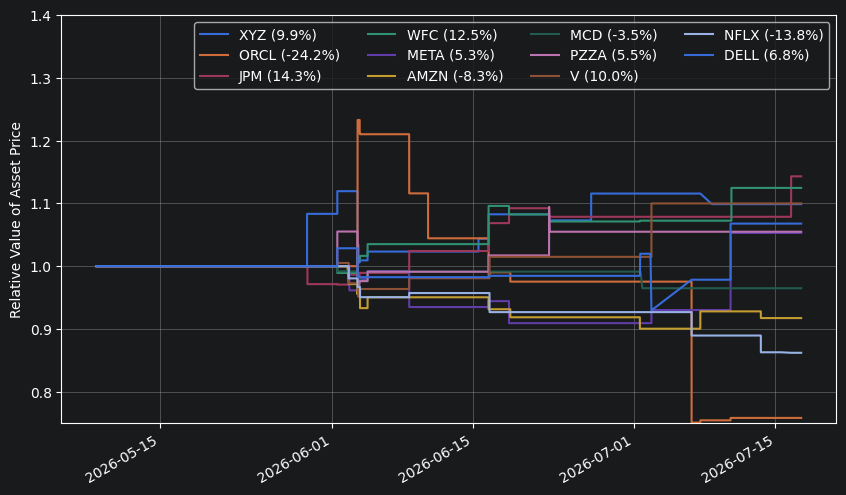

In [55]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(10, 6))
asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=4, loc='upper right')
plt.ylim(0.75, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [56]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-07-16 13:39:33+00:00    1.098801
2026-07-16 19:52:21+00:00    1.098801
2026-07-17 13:30:02+00:00    1.098801
2026-07-17 13:30:06+00:00    1.098801
2026-07-17 13:30:28+00:00    1.098801
Name: XYZ, Length: 477, dtype: float64

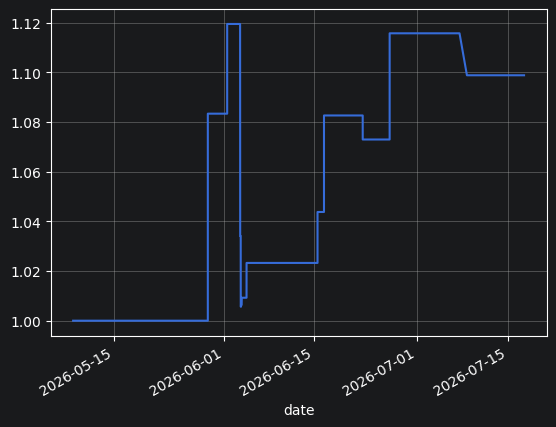

In [57]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [58]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
    .sort_values('date', ascending=False)
)
div_data

,date,amount,asset_type,notes
6,2026-07-17,0.22,INTU,$0.22 Dividend from Intuit
33,2026-07-15,0.01,TMO,$0.01 Dividend from Thermo Fisher Scientific
34,2026-07-15,0.16,OXY,$0.16 Dividend from Occidental Petroleum
35,2026-07-15,0.11,POR,$0.11 Dividend from Portland General Electric ...
32,2026-07-15,0.03,LECO,$0.03 Dividend from Lincoln Electric
61,2026-07-09,0.02,TSM,$0.02 Dividend from Taiwan Semiconductor Manuf...
65,2026-07-08,0.07,MRK,$0.07 Dividend from Merck
75,2026-07-06,0.04,BIV,$0.04 Dividend from Vanguard Intermediate Term...
76,2026-07-06,0.07,JEPI,$0.07 Dividend from JPMorgan Equity Premium In...
77,2026-07-06,0.05,BNDX,$0.05 Dividend from Vanguard Total Internation...


In [59]:
div_data['amount'].sum()

np.float64(4.5600000000000005)

In [60]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
150,2026-06-26,0.30,VFH,$0.30 Dividend from Vanguard Financials ETF
135,2026-07-01,0.27,HPQ,$0.27 Dividend from Hewlett Packard
157,2026-06-25,0.26,BBEU,$0.26 Dividend from JPMorgan BetaBuilders Euro...
6,2026-07-17,0.22,INTU,$0.22 Dividend from Intuit
296,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
153,2026-06-26,0.20,VDE,$0.20 Dividend from Energy ETF Vanguard
147,2026-06-26,0.18,VNQ,$0.18 Dividend from Vanguard Real Estate ETF
136,2026-07-01,0.17,KO,$0.17 Dividend from Coca-Cola
148,2026-06-26,0.17,DKS,$0.17 Dividend from Dick's Sporting Goods
167,2026-06-23,0.16,VSS,$0.16 Dividend from Vanguard FTSE All World ex...


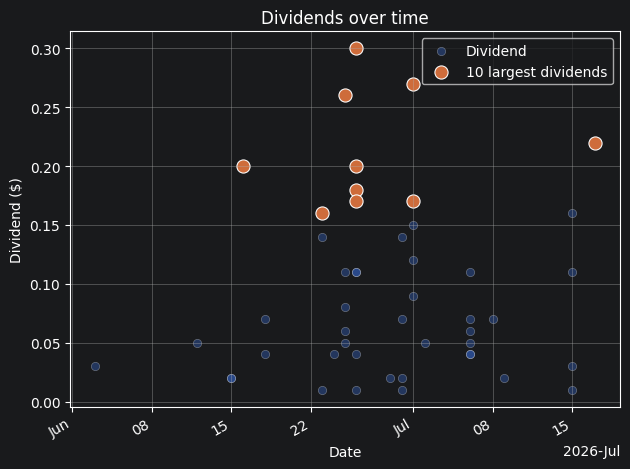

In [61]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [62]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
526,2026-06-03 13:30:10+00:00,-1.00,164.64,$1 Purchase of Energy ETF Vanguard,VDE
189,2026-06-22 13:30:14+00:00,-10.00,131.87,$10 Purchase of Vanguard Financials ETF,VFH
185,2026-06-22 13:30:18+00:00,-5.00,46.67,$5 Purchase of Vanguard Mortgage-Backed Securi...,VMBS
1,2026-07-17 13:30:06+00:00,-10.00,54.16,$10 Purchase of Vanguard Long-Treasury ETF,VGLT
478,2026-06-03 15:06:50+00:00,-10.00,159.33,$10 Purchase of Vanguard FTSE All World ex US ...,VSS
530,2026-06-03 13:30:09+00:00,-10.00,272.44,$10 Purchase of Vanguard Health Care ETF,VHT
167,2026-06-23 04:00:00+00:00,0.16,NaN,$0.16 Dividend from Vanguard FTSE All World ex...,VSS
230,2026-06-18 14:09:00+00:00,-5.00,687.48,$5 Purchase of Vanguard S&P 500 ETF,VOO
97,2026-07-02 13:30:00+00:00,-10.00,77.71,$10 Purchase of Vanguard Short Term Bond ETF,BSV
388,2026-06-03 19:46:16+00:00,-10.00,275.16,$10 Purchase of Vanguard Health Care ETF,VHT


In [63]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VONV    9
VOO     7
VMBS    7
VFH     6
VGLT    5
VDE     5
VCR     4
VNQ     4
VHT     4
VSS     4
BIV     3
BNDX    3
VTEB    3
VBR     3
VDC     3
VONG    3
BND     2
BSV     2
VGT     1
Name: count, dtype: int64

In [64]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
526,2026-06-03 13:30:10+00:00,-1.00,164.64,VDE,Energy ETF Vanguard
189,2026-06-22 13:30:14+00:00,-10.00,131.87,VFH,Vanguard Financials ETF
185,2026-06-22 13:30:18+00:00,-5.00,46.67,VMBS,Vanguard Mortgage-Backed Securities ETF
1,2026-07-17 13:30:06+00:00,-10.00,54.16,VGLT,Vanguard Long-Treasury ETF
478,2026-06-03 15:06:50+00:00,-10.00,159.33,VSS,Vanguard FTSE All World ex US Small Cap ETF
530,2026-06-03 13:30:09+00:00,-10.00,272.44,VHT,Vanguard Health Care ETF
167,2026-06-23 04:00:00+00:00,0.16,NaN,VSS,NaN
230,2026-06-18 14:09:00+00:00,-5.00,687.48,VOO,Vanguard S&P 500 ETF
97,2026-07-02 13:30:00+00:00,-10.00,77.71,BSV,Vanguard Short Term Bond ETF
388,2026-06-03 19:46:16+00:00,-10.00,275.16,VHT,Vanguard Health Care ETF


In [65]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VONV        Vanguard Russell 1000 Value ETF                8
VOO         Vanguard S&P 500 ETF                           6
VFH         Vanguard Financials ETF                        5
VMBS        Vanguard Mortgage-Backed Securities ETF        5
VGLT        Vanguard Long-Treasury ETF                     4
VDE         Energy ETF Vanguard                            4
VHT         Vanguard Health Care ETF                       3
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VCR         Vanguard Consumer Discretionary ETF            3
VONG        Vanguard Russell 1000 Growth ETF               2
VNQ         Vanguard Real Estate ETF                       2
BIV         Vanguard Intermediate Term Bond ETF            2
BND         Vanguard Total Bond Market ETF                 2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VBR         Small Cap Value ETF Vanguard                   2
BSV         Vanguard Short Te

In [66]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VONV,VOO,VMBS,VFH,VGLT,VDE,VCR,VNQ,VHT,VSS,BIV,BNDX,VTEB,VBR,VDC,VONG,BND,BSV,VGT
date,,,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:11+00:00,NaN,NaN,NaN,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
vanguard_trans_count

asset_type
VONV    9
VOO     7
VMBS    7
VFH     6
VGLT    5
VDE     5
VCR     4
VNQ     4
VHT     4
VSS     4
BIV     3
BNDX    3
VTEB    3
VBR     3
VDC     3
VONG    3
BND     2
BSV     2
VGT     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

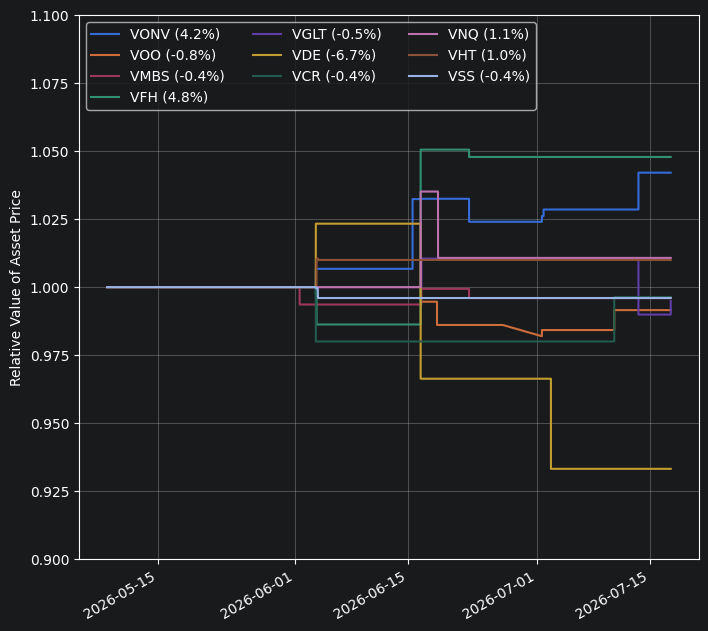

In [68]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.head(10).index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.ylim(0.9, 1.1)
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [69]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
5,2026-07-17 09:46:47+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
7,2026-07-16 22:04:59+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
30,2026-07-16 09:35:34+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
43,2026-07-10 21:11:17+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
59,2026-07-10 13:17:39+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
730,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
731,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
732,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
733,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [70]:
data_deposits['net_amount'].sum()

np.float64(6235.96)

In [71]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,70.0,89.085143,48.213537,1.0,62.5,100.0,100.0,200.0


In [72]:
data_deposits['net_amount'].cumsum()

5       100.00
7       200.00
30      300.00
43      400.00
59      500.00
        ...   
730    6130.96
731    6140.96
732    6190.96
733    6210.96
734    6235.96
Name: net_amount, Length: 70, dtype: float64

In [73]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
734,2026-05-26 19:39:34+00:00,25.00
733,2026-05-26 21:58:29+00:00,45.00
732,2026-05-27 00:43:01+00:00,95.00
731,2026-05-27 00:56:05+00:00,105.00
730,2026-05-27 00:56:27+00:00,205.00
...,...,...
59,2026-07-10 13:17:39+00:00,5835.96
43,2026-07-10 21:11:17+00:00,5935.96
30,2026-07-16 09:35:34+00:00,6035.96
7,2026-07-16 22:04:59+00:00,6135.96


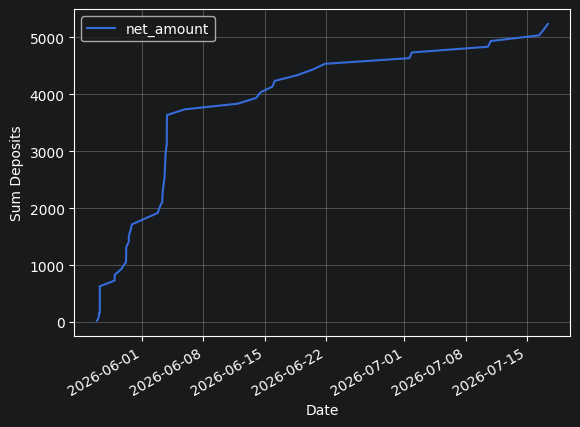

In [74]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [75]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.00
2026-05-26 21:58:29+00:00,0.0,20.00
2026-05-27 00:43:01+00:00,0.0,50.00
2026-05-27 00:56:05+00:00,0.0,10.00
2026-05-27 00:57:28+00:00,0.0,50.00
2026-05-27 03:29:11+00:00,0.0,5.00
2026-05-27 03:29:39+00:00,0.0,10.00
2026-05-27 03:30:06+00:00,0.0,10.00
2026-05-27 03:30:50+00:00,0.0,50.00


In [76]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    4900.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64